In [103]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

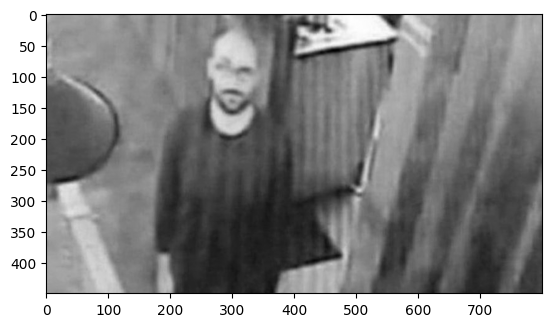

In [104]:
image = cv2.imread("backup.jpg")
backup = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(backup, cmap='gray')
plt.show()

Fungsi convolution diimplementasikan secara manual, cara kerjanya: gambar diberi padding nol di sekelilingnya sebesar setengah ukuran kernel, lalu setiap piksel dikalikan elemen per elemen dengan kernel menggunakan sliding window. Karena menggunakan dua nested, performanya akan sangat lambat untuk gambar berukuran besar. Output disimpan sebagai float32 untuk menjaga presisi.

In [105]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    
    padded = np.pad(img, pad_size, mode='constant')
    
    canvas = np.zeros_like(img).astype(np.float32)
 
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

Dua kernel 3x3 didefinisikan di sini. Kernel smoothing memiliki bobot lebih besar di tengah (1/5) dibanding tepian (1/10), menciptakan efek blur yang sedikit mempertahankan piksel pusat. Kernel sharpening menggunakan nilai tengah 8/9, menghasilkan efek penajaman. 

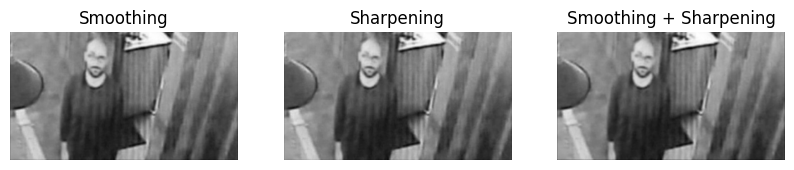

In [106]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])
Sharp = convolution(backup, kernelSharpening)
Smooth = convolution(backup, kernelSmoothing)
SmoothSharp = convolution(Smooth, kernelSharpening)

plt.figure(figsize=(10,15))
plt.subplot(1, 3, 1)
plt.imshow(Smooth, cmap='gray')
plt.title("Smoothing")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Sharp, cmap='gray')
plt.title("Sharpening")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(SmoothSharp, cmap='gray')
plt.title("Smoothing + Sharpening")
plt.axis('off')

plt.show()

edge untuk menghitung deteksi tepi menggunakan dua kernel gradien (horizontal dan vertikal), dan combine_edges untuk menggabungkan beberapa hasil deteksi tepi. Tiga operator disiapkan kernelnya: Prewitt yang sederhana dan seragam, Sobel yang memberi bobot lebih pada piksel terdekat, dan Roberts yang menggunakan kernel 2x2 diagonal.

In [107]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

def combine_edges(*edges):
    combined = sum(e.astype(np.float32) for e in edges)
    combined = combined * 255.0 / (np.max(combined) + 1e-8)
    return np.clip(combined, 0, 255).astype(np.uint8)

#Prewitt
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

#Sobel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

#Roberts
robertsX = np.array([
    [1,  0],
    [0, -1],
], dtype=np.float32)

robertsY = np.array([
    [ 0,  1],
    [-1,  0],
], dtype=np.float32)

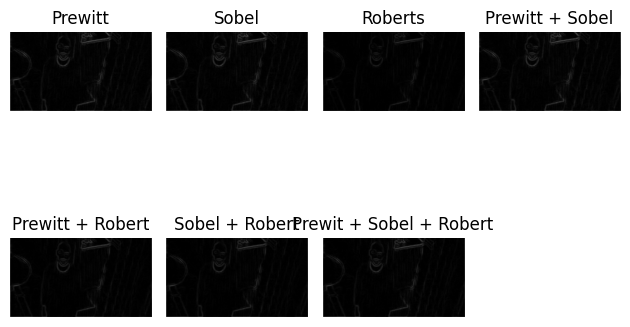

In [108]:
tepiSobel   = edge(SmoothSharp, sobelX, sobelY)
tepiPrewitt = edge(SmoothSharp, prewittX, prewittY)
tepiRoberts = edge(SmoothSharp, robertsX, robertsY)
combo_ps  = combine_edges(tepiPrewitt, tepiSobel)
combo_pr  = combine_edges(tepiPrewitt, tepiRoberts)
combo_sr  = combine_edges(tepiSobel,   tepiRoberts)
combo_psr = combine_edges(tepiPrewitt, tepiSobel, tepiRoberts)

plt.subplot(2, 4, 1)
plt.imshow(tepiPrewitt, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(tepiSobel, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(tepiRoberts, cmap='gray')
plt.title("Roberts")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(combo_ps, cmap="gray")
plt.title("Prewitt + Sobel")
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(combo_pr, cmap="gray")
plt.title("Prewitt + Robert")
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(combo_sr, cmap='gray')
plt.title("Sobel + Robert")
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(combo_psr, cmap='gray')
plt.title("Prewit + Sobel + Robert")
plt.axis('off')

plt.tight_layout()
plt.show()

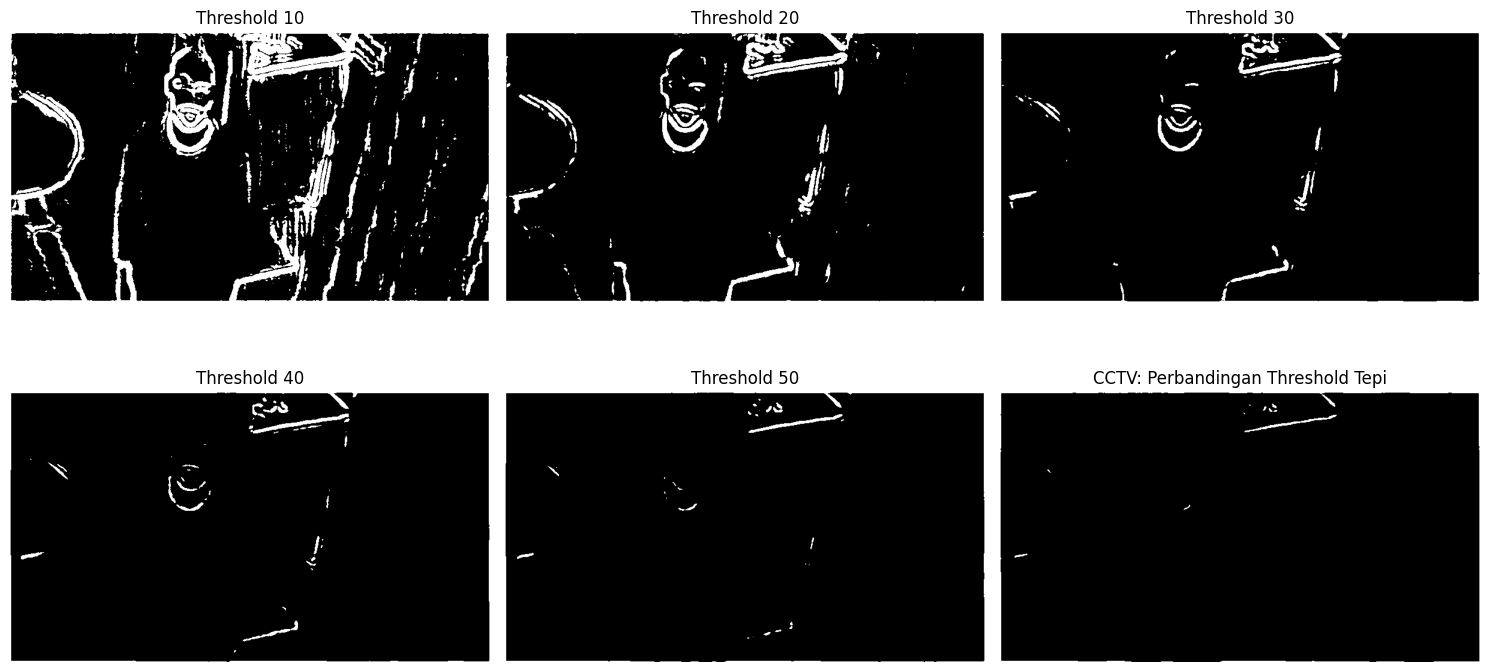

In [109]:
thresholds = [10, 20, 30, 40, 50, 60]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, thr in zip(axes.ravel(), thresholds):
    binary = (tepiSobel > thr).astype(np.uint8) * 255
    ax.imshow(binary, cmap='gray')
    ax.set_title(f'Threshold {thr}')
    ax.axis('off')
plt.title('CCTV: Perbandingan Threshold Tepi')
plt.tight_layout(); plt.show()

In [110]:
david_bgr  = cv2.imread('david.jpg')
david_rgb  = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2RGB)
david_gray = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2GRAY)

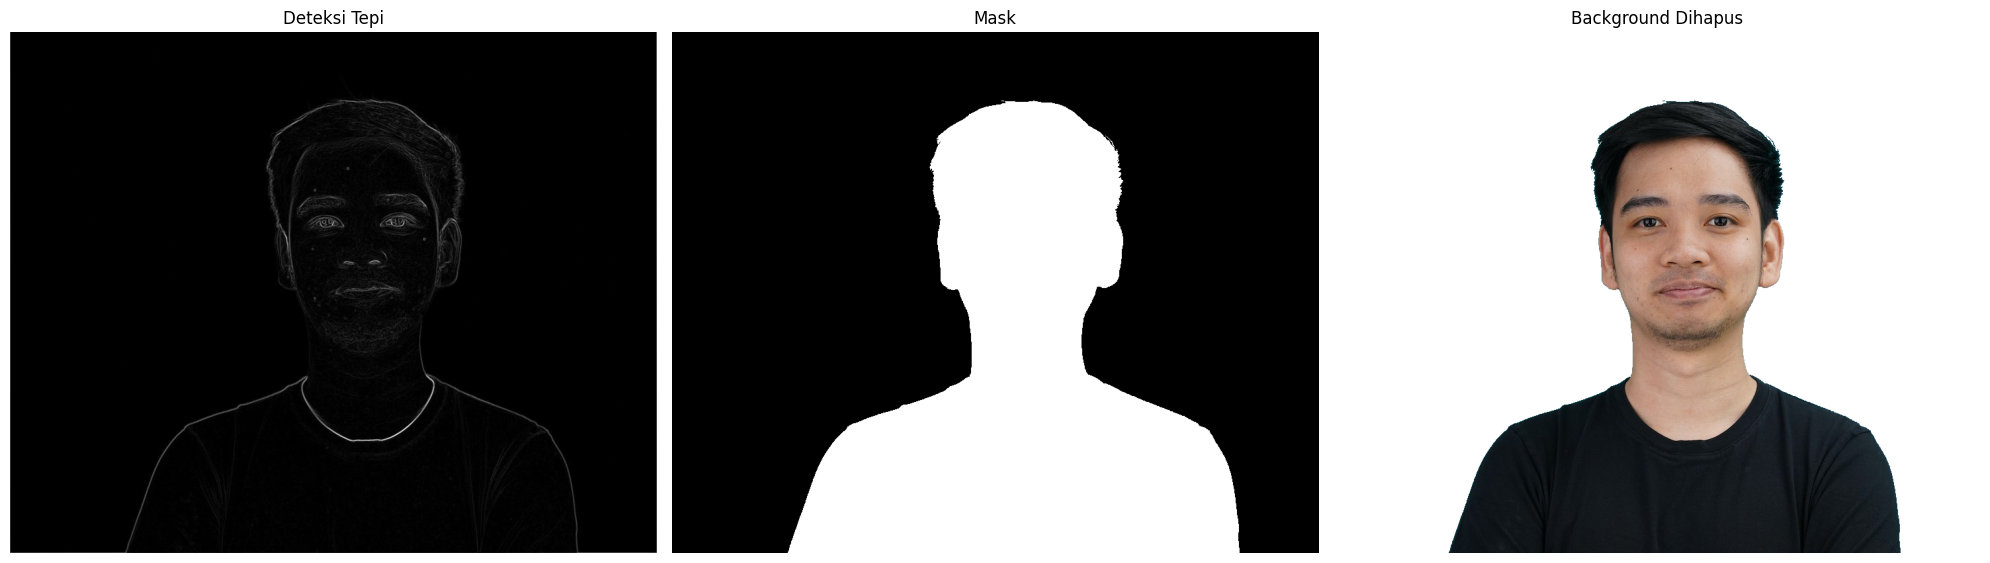

In [111]:
david_bgr  = cv2.imread('david.jpg')
david_rgb  = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2RGB)
david_gray = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2GRAY)

david_edge = edge(david_gray, sobelX, sobelY)

R = david_rgb[:,:,0].astype(np.int32)
G = david_rgb[:,:,1].astype(np.int32)
B = david_rgb[:,:,2].astype(np.int32)
bg_mask = ((G > R + 20) & (G > 80) & (B > R - 30)).astype(np.uint8) * 255
fg_mask = 255 - bg_mask

result = david_rgb.copy()
result[bg_mask == 255] = [255, 255, 255]

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.imshow(david_edge, cmap='gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(fg_mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title('Background Dihapus')
plt.axis('off')

plt.tight_layout()
plt.show()